## Entrenamiento de la red neuronal con Keras/TensorFlow

Nombres:
- Kevin García
- Karol Guerrero
- Juan José Márquez

### 1.1 Librerías necesarias

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os

### 1.2 Descarga y carga del dataset MNIST
60,000 imágenes de entrenamiento y 10,000 de prueba (dígitos 0-9, 28×28 píxeles)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Imágenes de entrenamiento: (60000, 28, 28)  |  Labels: (60000,)
Imágenes de prueba:        (10000, 28, 28)   |  Labels: (10000,)


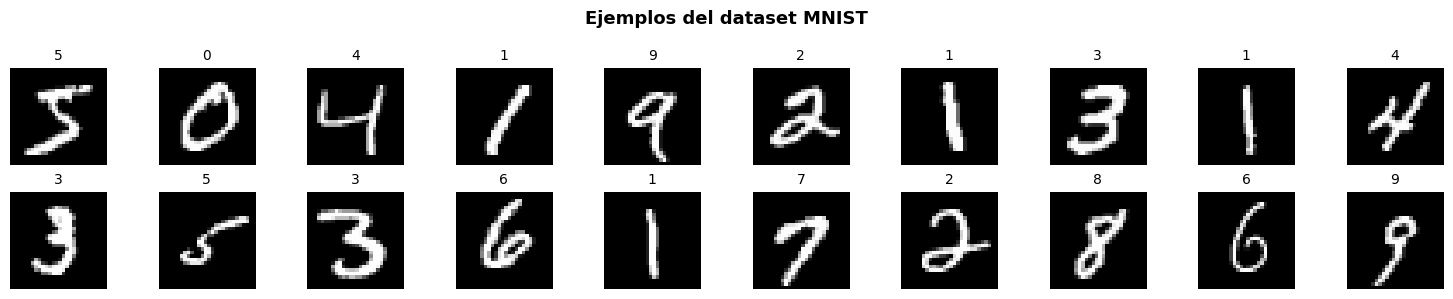

In [2]:
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(f'Imágenes de entrenamiento: {train_images.shape}  |  Labels: {train_labels.shape}')
print(f'Imágenes de prueba:        {test_images.shape}   |  Labels: {test_labels.shape}')

# Visualizar algunos ejemplos
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_images[i], cmap='gray')
    ax.set_title(str(train_labels[i]), fontsize=10)
    ax.axis('off')
plt.suptitle('Ejemplos del dataset MNIST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.3 Normalización de datos
Se dividen los valores entre 255.0 para llevar los píxeles al rango [0, 1]

In [3]:
train_images = train_images / 255.0
test_images  = test_images  / 255.0

print(f'Rango de valores después de normalizar: [{train_images.min():.1f}, {train_images.max():.1f}]')

Rango de valores después de normalizar: [0.0, 1.0]


### 1.4 Definir la arquitectura de la red neuronal

| Capa | Tipo    | Neuronas | Activación |
|------|---------|----------|-----------|
| 0    | Flatten | 784      | —         |
| 1    | Dense   | 128      | ReLU      |
| 2    | Dense   | 128      | ReLU      |
| 3    | Dense   | 128      | ReLU      |
| 4    | Dense   | 128      | ReLU      |
| 5    | Dense   | 10       | Softmax   |

In [4]:
model = keras.Sequential([
    # Convierte la matriz 28x28 en un vector de 784 neuronas
    keras.layers.Flatten(input_shape=(28, 28)),
    # 4 capas ocultas con 128 neuronas y activación ReLU
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    # Capa de salida: 10 neuronas (una por dígito) con Softmax
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,306 (591.04 KB)

 Trainable params: 151,306 (591.04 KB)

 Non-trainable params: 0 (0.00 B)

### 1.5 Entrenar la red neuronal

In [5]:
print('Iniciando entrenamiento en GPU...\n')
history = model.fit(
    train_images, train_labels,
    epochs=10,
    validation_split=0.1,
    batch_size=128,
    verbose=1
)

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\n Precisión en pruebas: {test_acc:.4f} ({test_acc*100:.2f}%)')

Iniciando entrenamiento en GPU...

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9051 - loss: 0.3249 - val_accuracy: 0.9633 - val_loss: 0.1269
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9619 - loss: 0.1203 - val_accuracy: 0.9643 - val_loss: 0.1139
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9742 - loss: 0.0861 - val_accuracy: 0.9763 - val_loss: 0.0809
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9809 - loss: 0.0627 - val_accuracy: 0.9753 - val_loss: 0.0878
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9837 - loss: 0.0510 - val_accuracy: 0.9775 - val_loss: 0.0770
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9865 - loss: 0.0430 - val_accuracy: 0.9785 - val_loss: 0.0819
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9886 - loss: 0.0352 - val_accuracy: 0.9753 - val_loss: 0.0934
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.990

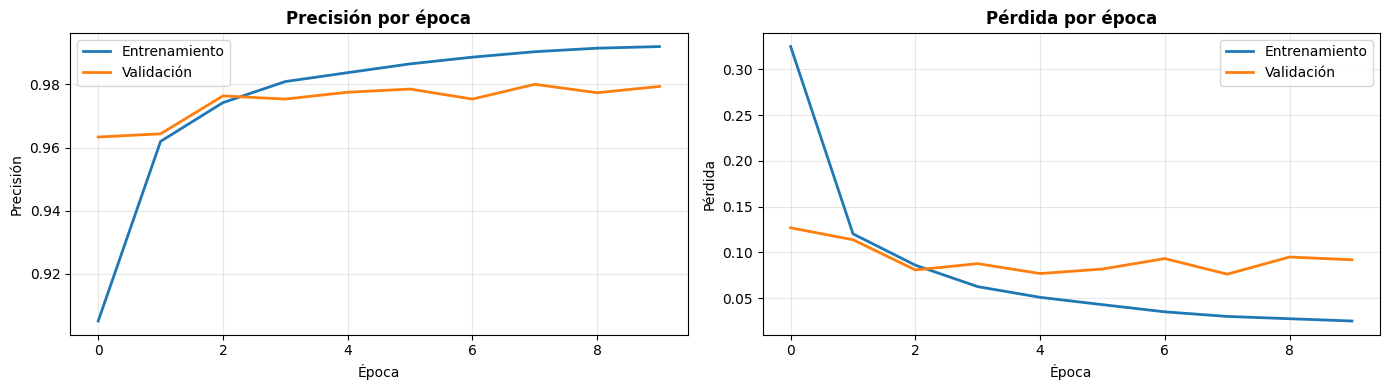

In [6]:
# Gráfico de precisión y pérdida durante el entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['accuracy'],     label='Entrenamiento', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validación',    linewidth=2)
ax1.set_title('Precisión por época', fontweight='bold')
ax1.set_xlabel('Época'); ax1.set_ylabel('Precisión')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Entrenamiento', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validación',    linewidth=2)
ax2.set_title('Pérdida por época', fontweight='bold')
ax2.set_xlabel('Época'); ax2.set_ylabel('Pérdida')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Parte 2 — Extracción de parámetros (pesos y bias)

In [7]:
# Extraer pesos y bias de las capas ocultas (1 a 4) y la capa de salida (5)
parametros = {}

for i in [1, 2, 3, 4, 5]:
    capa = model.layers[i]
    weights, bias = capa.get_weights()
    parametros[f'W{i}'] = weights
    parametros[f'B{i}'] = bias
    print(f'Capa {i}: W{i}.shape = {weights.shape}  |  B{i}.shape = {bias.shape}')

# Guardar parámetros en archivo .npz para usarlos en CUDA
np.savez('parametros_red.npz', **parametros)
print('\nParámetros guardados en parametros_red.npz')

Capa 1: W1.shape = (784, 128)  |  B1.shape = (128,)
Capa 2: W2.shape = (128, 128)  |  B2.shape = (128,)
Capa 3: W3.shape = (128, 128)  |  B3.shape = (128,)
Capa 4: W4.shape = (128, 128)  |  B4.shape = (128,)
Capa 5: W5.shape = (128, 10)  |  B5.shape = (10,)

Parámetros guardados en parametros_red.npz


In [8]:
# Verificar que los parámetros se guardaron correctamente
datos = np.load('parametros_red.npz')
print('Claves guardadas:', list(datos.keys()))
for k in datos.keys():
    print(f'  {k}: shape={datos[k].shape}, dtype={datos[k].dtype}')

Claves guardadas: ['W1', 'B1', 'W2', 'B2', 'W3', 'B3', 'W4', 'B4', 'W5', 'B5']
  W1: shape=(784, 128), dtype=float32
  B1: shape=(128,), dtype=float32
  W2: shape=(128, 128), dtype=float32
  B2: shape=(128,), dtype=float32
  W3: shape=(128, 128), dtype=float32
  B3: shape=(128,), dtype=float32
  W4: shape=(128, 128), dtype=float32
  B4: shape=(128,), dtype=float32
  W5: shape=(128, 10), dtype=float32
  B5: shape=(10,), dtype=float32


---
## Parte 3 — Implementación de Forward Propagation en CUDA (PyCUDA)

### 3.1 Instalar PyCUDA

In [9]:
!pip install pycuda -q
print('PyCUDA instalado ✅')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 29.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 12.4 MB/s eta 0:00:00
PyCUDA instalado ✅


### 3.2 Kernel CUDA — Multiplicación de matrices + bias

In [11]:
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule

# ------------------------------------------------------------------ #
#  Kernels CUDA escritos en C                                          #
# ------------------------------------------------------------------ #
cuda_code = """
// --------------------------------------------------------
// Kernel: multiplicación de matrices + bias
// X      : [batch x in_features]
// W      : [in_features x out_features]
// B      : [out_features]
// result : [batch x out_features]
// --------------------------------------------------------
__global__ void matmul_bias(
    const float* X, const float* W, const float* B,
    float* result,
    int batch, int in_feat, int out_feat)
{
    int row = blockIdx.y * blockDim.y + threadIdx.y;  // fila (batch)
    int col = blockIdx.x * blockDim.x + threadIdx.x;  // col (out_feat)

    if (row < batch && col < out_feat) {
        float val = 0.0f;
        for (int k = 0; k < in_feat; k++) {
            val += X[row * in_feat + k] * W[k * out_feat + col];
        }
        result[row * out_feat + col] = val + B[col];
    }
}

// --------------------------------------------------------
// Kernel: activación ReLU  f(z) = max(0, z)
// --------------------------------------------------------
__global__ void relu_activation(float* data, int n)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        data[idx] = fmaxf(0.0f, data[idx]);
    }
}

// --------------------------------------------------------
// Kernel: Softmax (versión numérica estable)
//   Se aplica por fila (un dígito a la vez)
// --------------------------------------------------------
__global__ void softmax(float* data, int batch, int classes)
{
    int row = blockIdx.x * blockDim.x + threadIdx.x;
    if (row >= batch) return;

    float* row_ptr = data + row * classes;

    // Encontrar máximo para estabilidad numérica
    float max_val = row_ptr[0];
    for (int j = 1; j < classes; j++)
        if (row_ptr[j] > max_val) max_val = row_ptr[j];

    // Calcular exponenciales y suma
    float sum = 0.0f;
    for (int j = 0; j < classes; j++) {
        row_ptr[j] = expf(row_ptr[j] - max_val);
        sum += row_ptr[j];
    }

    // Normalizar
    for (int j = 0; j < classes; j++)
        row_ptr[j] /= sum;
}
"""

# Compilar los kernels
mod = SourceModule(cuda_code)
matmul_bias_kernel   = mod.get_function('matmul_bias')
relu_kernel          = mod.get_function('relu_activation')
softmax_kernel       = mod.get_function('softmax')

print('✅ Kernels CUDA compilados correctamente')

✅ Kernels CUDA compilados correctamente


### 3.3 Función de Forward Propagation en GPU

In [12]:
def forward_gpu(X_input, parametros):
    """
    Forward propagation optimizado en GPU (sin copias intermedias).
    Arquitectura: 784 -> 128x4 (ReLU) -> 10 (Softmax)
    """

    BLOCK = 16

    # ---- Preprocesamiento ----
    if X_input.ndim == 3:
        X_input = X_input.reshape(X_input.shape[0], -1)

    A = X_input.astype(np.float32)
    batch = A.shape[0]

    # ---- Copiar input UNA sola vez ----
    d_A = cuda.mem_alloc(A.nbytes)
    cuda.memcpy_htod(d_A, A)

    # ---- Forward capas ocultas ----
    for i in range(1, 5):
        W = parametros[f'W{i}'].astype(np.float32)
        B = parametros[f'B{i}'].astype(np.float32)

        in_f, out_f = W.shape

        # Reservar memoria GPU
        d_W = cuda.mem_alloc(W.nbytes)
        d_B = cuda.mem_alloc(B.nbytes)
        d_Z = cuda.mem_alloc(batch * out_f * 4)

        # Copiar pesos
        cuda.memcpy_htod(d_W, W)
        cuda.memcpy_htod(d_B, B)

        # Configuración de grid
        grid_x = int(np.ceil(out_f / BLOCK))
        grid_y = int(np.ceil(batch / BLOCK))

        # Matmul + bias
        matmul_bias_kernel(
            d_A, d_W, d_B, d_Z,
            np.int32(batch), np.int32(in_f), np.int32(out_f),
            block=(BLOCK, BLOCK, 1),
            grid=(grid_x, grid_y, 1)
        )

        # ReLU
        n_elem = batch * out_f
        relu_kernel(
            d_Z, np.int32(n_elem),
            block=(256, 1, 1),
            grid=(int(np.ceil(n_elem / 256)), 1, 1)
        )

        # Reutilizar buffer (swap)
        d_A = d_Z

    # ---- Capa de salida ----
    W5 = parametros['W5'].astype(np.float32)
    B5 = parametros['B5'].astype(np.float32)

    in_f5, out_f5 = W5.shape

    d_W5 = cuda.mem_alloc(W5.nbytes)
    d_B5 = cuda.mem_alloc(B5.nbytes)
    d_Z5 = cuda.mem_alloc(batch * out_f5 * 4)

    cuda.memcpy_htod(d_W5, W5)
    cuda.memcpy_htod(d_B5, B5)

    grid_x = int(np.ceil(out_f5 / BLOCK))
    grid_y = int(np.ceil(batch / BLOCK))

    matmul_bias_kernel(
        d_A, d_W5, d_B5, d_Z5,
        np.int32(batch), np.int32(in_f5), np.int32(out_f5),
        block=(BLOCK, BLOCK, 1),
        grid=(grid_x, grid_y, 1)
    )

    # Softmax
    softmax_kernel(
        d_Z5, np.int32(batch), np.int32(out_f5),
        block=(256, 1, 1),
        grid=(int(np.ceil(batch / 256)), 1, 1)
    )

    # ---- Copiar resultado UNA sola vez ----
    probs = np.empty((batch, out_f5), dtype=np.float32)
    cuda.memcpy_dtoh(probs, d_Z5)

    return probs

### 3.4 Evaluación de la implementación CUDA vs Keras

In [13]:
import time

# Cargar parámetros
datos = np.load('parametros_red.npz')
params = {k: datos[k] for k in datos.keys()}

# ---- Evaluación en un batch de 1000 imágenes ----
N = 1000
X_test = test_images[:N]
y_test = test_labels[:N]

# Forward CUDA
t0 = time.time()
probs_cuda = forward_gpu(X_test, params)
t_cuda = time.time() - t0
preds_cuda = np.argmax(probs_cuda, axis=1)
acc_cuda = np.mean(preds_cuda == y_test)

# Forward Keras (referencia)
t0 = time.time()
probs_keras = model.predict(X_test, verbose=0)
t_keras = time.time() - t0
preds_keras = np.argmax(probs_keras, axis=1)
acc_keras = np.mean(preds_keras == y_test)

print(f'Implementación CUDA  — Precisión: {acc_cuda*100:.2f}%  | Tiempo: {t_cuda*1000:.1f} ms')
print(f'Implementación Keras — Precisión: {acc_keras*100:.2f}%  | Tiempo: {t_keras*1000:.1f} ms')
print(f'\nCoincidencia entre predicciones: {np.mean(preds_cuda == preds_keras)*100:.2f}%')

Implementación CUDA  — Precisión: 97.70%  | Tiempo: 8.0 ms
Implementación Keras — Precisión: 97.70%  | Tiempo: 837.4 ms

Coincidencia entre predicciones: 100.00%


---
## Parte 4 — 🖼️ Prueba con imagen propia

Puedes **dibujar un dígito** con el ratón/lápiz del iPad, o **subir una imagen** desde tu dispositivo.

### Opción A — Canvas interactivo (dibujar con ratón o Apple Pencil)

🎨 Canvas listo. Dibuja y guarda.
✅ Imagen guardada y preprocesada correctamente (estilo MNIST)


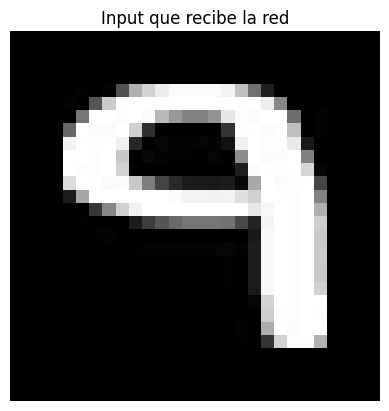

In [20]:
from IPython.display import display, HTML
import base64, io, os
import numpy as np
from PIL import Image
import google.colab.output

# ------------------------------------------------------------------
# Canvas mejorado
# ------------------------------------------------------------------
canvas_html = """
<style>
  #canvas-container {
    display: flex;
    flex-direction: column;
    align-items: center;
    font-family: 'Segoe UI', sans-serif;
    gap: 12px;
  }
  #drawCanvas {
    border: 3px solid #4f46e5;
    border-radius: 12px;
    background: #000;
    cursor: crosshair;
    touch-action: none;
    box-shadow: 0 4px 20px rgba(79,70,229,0.4);
  }
  .btn-row { display: flex; gap: 10px; }
  .btn {
    padding: 10px 22px;
    border: none;
    border-radius: 8px;
    font-size: 15px;
    font-weight: 600;
    cursor: pointer;
  }
  #clearBtn   { background: #ef4444; color: #fff; }
  #saveBtn    { background: #22c55e; color: #fff; }
</style>

<div id="canvas-container">
  <p style="font-weight:700;font-size:16px;margin:0">✏️ Dibuja un dígito (0-9)</p>
  <canvas id="drawCanvas" width="280" height="280"></canvas>
  <div class="btn-row">
    <button class="btn" id="clearBtn">🗑️ Limpiar</button>
    <button class="btn" id="saveBtn">💾 Guardar imagen</button>
  </div>
</div>

<script>
const canvas = document.getElementById('drawCanvas');
const ctx    = canvas.getContext('2d');

let drawing = false;

function getPos(e) {
  const rect = canvas.getBoundingClientRect();
  const t = e.touches ? e.touches[0] : e;
  return { x: t.clientX - rect.left, y: t.clientY - rect.top };
}

function start(e) {
  drawing = true;
  const p = getPos(e);
  ctx.beginPath();
  ctx.moveTo(p.x, p.y);
}

function draw(e) {
  if (!drawing) return;
  const p = getPos(e);

  ctx.lineTo(p.x, p.y);
  ctx.strokeStyle = '#ffffff';
  ctx.lineWidth = 18;   // 🔥 Grosor más cercano a MNIST
  ctx.lineCap = 'round';
  ctx.lineJoin = 'round';
  ctx.stroke();
}

function stop() {
  drawing = false;
  ctx.beginPath();
}

canvas.addEventListener('mousedown', start);
canvas.addEventListener('mousemove', draw);
canvas.addEventListener('mouseup', stop);
canvas.addEventListener('mouseleave', stop);

canvas.addEventListener('touchstart', start);
canvas.addEventListener('touchmove', draw);
canvas.addEventListener('touchend', stop);

document.getElementById('clearBtn').onclick = () => {
  ctx.clearRect(0,0,canvas.width,canvas.height);
};

document.getElementById('saveBtn').onclick = () => {
  const dataURL = canvas.toDataURL('image/png');
  const b64 = dataURL.split(',')[1];
  google.colab.kernel.invokeFunction('canvas_save', [b64], {});
};
</script>
"""

display(HTML(canvas_html))

# ------------------------------------------------------------------
# Preprocesamiento estilo MNIST (CORREGIDO)
# ------------------------------------------------------------------
def canvas_save(b64_str):
    img_bytes = base64.b64decode(b64_str)
    img = Image.open(io.BytesIO(img_bytes)).convert('L')

    arr = np.array(img)

    # --- Recorte automático del dígito ---
    coords = np.column_stack(np.where(arr > 30))
    if len(coords) > 0:
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        img = img.crop((x_min, y_min, x_max, y_max))

    # --- Redimensionar manteniendo proporción ---
    img = img.resize((20, 20), Image.LANCZOS)

    # --- Centrar en canvas 28x28 ---
    new_img = Image.new('L', (28, 28), 0)
    new_img.paste(img, (4, 4))

    # --- Normalización ---
    arr = np.array(new_img, dtype=np.float32) / 255.0


    np.save('canvas_digit.npy', arr)

    print('✅ Imagen guardada y preprocesada correctamente (estilo MNIST)')
    import matplotlib.pyplot as plt
    plt.imshow(arr, cmap='gray')
    plt.title("Input que recibe la red")
    plt.axis('off')
    plt.show()

google.colab.output.register_callback('canvas_save', canvas_save)

print("🎨 Canvas listo. Dibuja y guarda.")

### Opción B — Subir imagen desde archivo (paint, foto, etc.)

In [ ]:
from google.colab import files
from PIL import Image
import io

print('Selecciona una imagen PNG/JPG de tu dígito (28×28 o cualquier tamaño):')
uploaded = files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    img = Image.open(io.BytesIO(uploaded[fname])).convert('L')  # escala de grises
    img = img.resize((28, 28), Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0

    # Si la imagen es negra sobre blanco, invertirla (MNIST es blanco sobre negro)
    if arr.mean() > 0.5:
        arr = 1.0 - arr
        print('ℹ️  Imagen invertida (fondo blanco detectado)')

    np.save('canvas_digit.npy', arr)

    plt.figure(figsize=(3, 3))
    plt.imshow(arr, cmap='gray')
    plt.title('Imagen cargada (28×28)', fontweight='bold')
    plt.axis('off')
    plt.show()
    print('✅ Imagen guardada como canvas_digit.npy')
else:
    print('No se subió ningún archivo.')

Selecciona una imagen PNG/JPG de tu dígito (28×28 o cualquier tamaño):


No se subió ningún archivo.


### Predicción con la imagen dibujada o subida

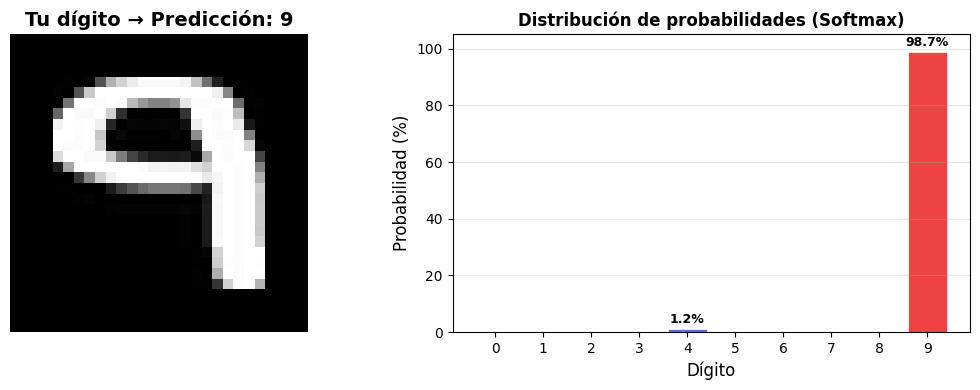


🎯 La red neuronal CUDA predice: 9
   Confianza: 98.72%

Probabilidades por dígito:
  0:                                              0.0%
  1:                                              0.0%
  2:                                              0.0%
  3:                                              0.0%
  4:                                              1.2%
  5:                                              0.1%
  6:                                              0.0%
  7:                                              0.0%
  8:                                              0.0%
  9: ███████████████████████████████████████     98.7% ← PREDICCIÓN


In [21]:
# Cargar la imagen guardada (ya sea del canvas o de archivo)
if not os.path.exists('canvas_digit.npy'):
    print('⚠️  No hay imagen guardada. Usa la Opción A o B primero.')
else:
    # Recompilar kernels para asegurar contexto CUDA válido
    mod = SourceModule(cuda_code)
    matmul_bias_kernel = mod.get_function('matmul_bias')
    relu_kernel        = mod.get_function('relu_activation')
    softmax_kernel     = mod.get_function('softmax')

    digito = np.load('canvas_digit.npy')
    X_dig  = digito.reshape(1, 784)

    # ---- Predicción con CUDA ----
    probs = forward_gpu(X_dig, params)[0]
    pred  = np.argmax(probs)

    # ---- Visualización ----
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    ax1.imshow(digito, cmap='gray')
    ax1.set_title(f'Tu dígito → Predicción: {pred}', fontsize=14, fontweight='bold')
    ax1.axis('off')

    colores = ['#ef4444' if i == pred else '#6366f1' for i in range(10)]
    bars = ax2.bar(range(10), probs * 100, color=colores, edgecolor='white', linewidth=0.5)
    ax2.set_xticks(range(10))
    ax2.set_xlabel('Dígito', fontsize=12)
    ax2.set_ylabel('Probabilidad (%)', fontsize=12)
    ax2.set_title('Distribución de probabilidades (Softmax)', fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 105)
    ax2.grid(axis='y', alpha=0.3)

    for bar, p in zip(bars, probs):
        if p > 0.01:
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{p*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f'\n🎯 La red neuronal CUDA predice: {pred}')
    print(f'   Confianza: {probs[pred]*100:.2f}%')
    print(f'\nProbabilidades por dígito:')
    for i, p in enumerate(probs):
        bar_str = '█' * int(p * 40)
        marker  = ' ← PREDICCIÓN' if i == pred else ''
        print(f'  {i}: {bar_str:<42} {p*100:5.1f}%{marker}')

---
## Parte 5 — Benchmark: Comparativa CPU vs GPU

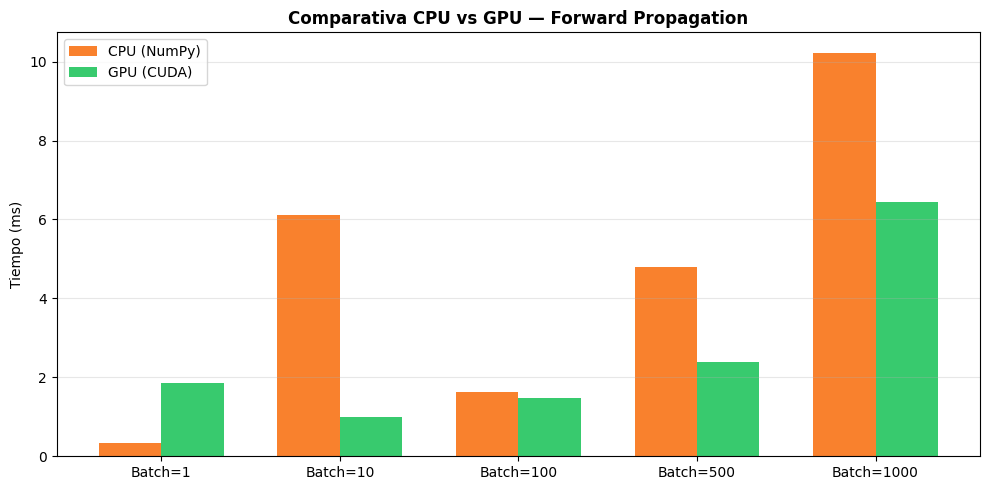


Resultados:
   Batch |   CPU (ms) |   GPU (ms) |  Speedup
---------------------------------------------
       1 |       0.34 |       1.85 |    0.18x
      10 |       6.12 |       0.99 |    6.18x
     100 |       1.64 |       1.49 |    1.10x
     500 |       4.78 |       2.40 |    1.99x
    1000 |      10.23 |       6.44 |    1.59x


In [22]:
def forward_cpu(X_input, params):
    """Misma red neuronal, corriendo en CPU con NumPy"""
    if X_input.ndim == 3:
        X_input = X_input.reshape(X_input.shape[0], -1)
    A = X_input.astype(np.float32)
    for i in range(1, 5):
        W = params[f'W{i}'].astype(np.float32)
        B = params[f'B{i}'].astype(np.float32)
        A = np.maximum(0, A @ W + B)    # matmul + bias + ReLU
    # Capa de salida con Softmax
    Z  = A @ params['W5'].astype(np.float32) + params['B5'].astype(np.float32)
    Z -= Z.max(axis=1, keepdims=True)   # estabilidad numérica
    E  = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)

batch_sizes = [1, 10, 100, 500, 1000]
tiempos_cpu, tiempos_gpu = [], []

for bs in batch_sizes:
    X_b = test_images[:bs]

    # CPU
    t0 = time.time()
    for _ in range(5): forward_cpu(X_b, params)
    tiempos_cpu.append((time.time() - t0) / 5 * 1000)

    # GPU
    t0 = time.time()
    for _ in range(5): forward_gpu(X_b, params)
    tiempos_gpu.append((time.time() - t0) / 5 * 1000)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(batch_sizes))
w = 0.35
ax.bar(x - w/2, tiempos_cpu, w, label='CPU (NumPy)', color='#f97316', alpha=0.9)
ax.bar(x + w/2, tiempos_gpu, w, label='GPU (CUDA)',  color='#22c55e', alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels([f'Batch={b}' for b in batch_sizes])
ax.set_ylabel('Tiempo (ms)'); ax.set_title('Comparativa CPU vs GPU — Forward Propagation', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print('\nResultados:')
print(f'{"Batch":>8} | {"CPU (ms)":>10} | {"GPU (ms)":>10} | {"Speedup":>8}')
print('-' * 45)
for b, tc, tg in zip(batch_sizes, tiempos_cpu, tiempos_gpu):
    sp = tc / tg if tg > 0 else 0
    print(f'{b:>8} | {tc:>10.2f} | {tg:>10.2f} | {sp:>7.2f}x')

---
## Parte 6 — Visualización de la red completa (bonus)

/tmp/ipykernel_2508/1196869501.py:18: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


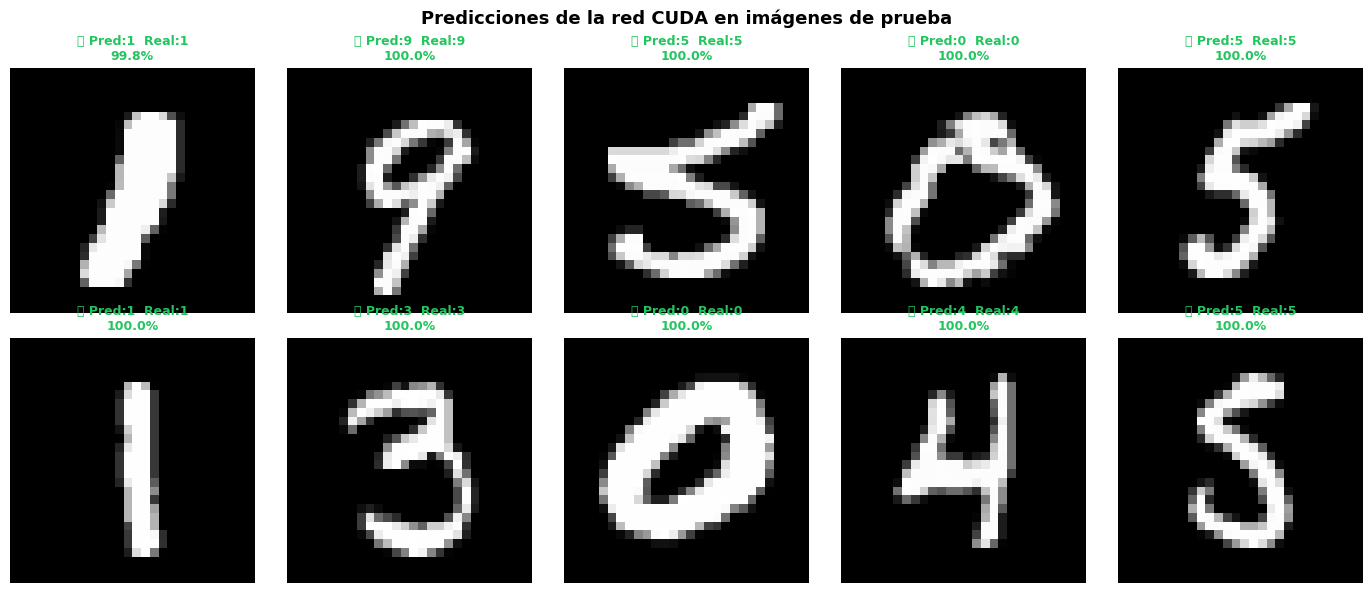

In [23]:
# Mostrar 10 predicciones aleatorias del conjunto de prueba
idx = np.random.choice(len(test_images), 10, replace=False)
X_sample = test_images[idx]
y_sample = test_labels[idx]
probs_sample = forward_gpu(X_sample, params)
preds_sample = np.argmax(probs_sample, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, img, true_l, pred_l, prb in zip(axes.flat, X_sample, y_sample, preds_sample, probs_sample):
    ax.imshow(img, cmap='gray')
    color = '#22c55e' if pred_l == true_l else '#ef4444'
    icon  = '✅' if pred_l == true_l else '❌'
    ax.set_title(f'{icon} Pred:{pred_l}  Real:{true_l}\n{prb[pred_l]*100:.1f}%',
                 color=color, fontweight='bold', fontsize=9)
    ax.axis('off')

plt.suptitle('Predicciones de la red CUDA en imágenes de prueba', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()